# ============================================================
# PROJETO: RISCO DE DEFASAGEM ESCOLAR
# ============================================================

Objetivo:
Realizar análise exploratória dos dados (EDA) para compreender o perfil dos alunos e identificar fatores associados ao risco de defasagem escolar.

## Carregamento dos Dados

🔹 1. Importações e leitura da base

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid", palette="pastel")

pd.set_option('display.max_columns', None)

# Carregar base
df_2022 = pd.read_excel("../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx", sheet_name="PEDE2022")
df_2023 = pd.read_excel("../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx", sheet_name="PEDE2023")
df_2024 = pd.read_excel("../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx", sheet_name="PEDE2024")

🔹 2. Visão geral da base

In [3]:
print("Dimensão do dataset 2022:", df_2022.shape)
print("Dimensão do dataset 2023: ", df_2023.shape)
print("Dimensão do dataset 2024:", df_2024.shape)

Dimensão do dataset 2022: (860, 42)
Dimensão do dataset 2023:  (1014, 48)
Dimensão do dataset 2024: (1156, 50)


Durante a etapa de entendimento dos dados, foi possível identificar que a estrutura dos datasets sofreu modificações ao longo dos anos analisados (2022, 2023 e 2024). Observa-se que novas variáveis foram incorporadas progressivamente, além de ajustes na nomenclatura de algumas colunas.

In [4]:
print ('nomes das colunas dataset 2022:',df_2022.columns)
print ('nomes das colunas dataset 2023:',df_2023.columns)
print ('nomes das colunas dataset 2024:',df_2024.columns)

nomes das colunas dataset 2022: Index(['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero',
       'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21',
       'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA',
       'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN',
       'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV'],
      dtype='str')
nomes das colunas dataset 2023: Index(['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado',
       'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23',
       'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1',
       'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3',
       'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'I

A partir do output anterior, é possível identificar que o dataset apresenta ausência de padronização e necessita de tratamento. Como etapa inicial, vamos realizar uma limpeza adequada dos dados, garantindo consistência nos nomes das colunas, tipos de variáveis e valores ausentes ou inconsistentes.

🔹 3. Padronização & Consolidação da Base

In [5]:
#padronização de colunas
colunas_2022 = { 
    "RA": "RA", 
    "Fase": "FASE", 
    "Turma": "TURMA", 
    "Nome": "NOME_ALUNO", 
    "Ano nasc": "ANO_NASC", 
    "Idade 22": "IDADE", 
    "Gênero": "GENERO", 
    "Ano ingresso": "ANO_INGRESSO", 
    "Instituição de ensino": "INSTITUICAO_ENSINO", 
    "Pedra 20": "PEDRA_2020", 
    "Pedra 21": "PEDRA_2021", 
    "Pedra 22": "PEDRA_2022", 
    "INDE 22": "INDE_2022", 
    "Cg": "GC", 
    "Cf": "CF", 
    "Ct": "CT", 
    "Nº Av": "N_AVALIADOR", 
    "Avaliador1": "AVALIADOR_1", 
    "Rec Av1": "REC_EQUIPE_1", 
    "Avaliador2": "AVALIADOR_2", 
    "Rec Av2": "REC_EQUIPE_2", 
    "Avaliador3": "AVALIADOR_3", 
    "Rec Av3": "REC_EQUIPE_3", 
    "Avaliador4": "AVALIADOR_4", 
    "Rec Av4": "REC_EQUIPE_4", 
    "IAA": "IAA", 
    "IEG": "IEG", 
    "IPS": "IPS", 
    "Rec Psicologia": "REC_PSICO", 
    "IDA": "IDA", 
    "Matem": "NOTA_MATEM", 
    "Portug": "NOTA_PORT", 
    "Inglês": "NOTA_INGL", 
    "Indicado": "INDC_BOLSA", 
    "Atingiu PV": "ATING_PV", 
    "IPV": "IND_PV", 
    "IAN": "IAN", 
    "Fase ideal": "NIVEL_IDEAL", 
    "Defas": "DEFASAGEM", 
    "Destaque IEG": "DESTAQUE_IEG", 
    "Destaque IDA": "DESTAQUE_IDA", 
    "Destaque IPV": "DESTAQUE_IPV" }

df_2022 = df_2022.rename(columns=colunas_2022)


In [6]:
#padronização de colunas
#colunas duplicadas no dataset 2023 que foram removidas antes da renomeação
df_2023.drop(["INDE 23", "Pedra 23"], axis=1, inplace=True)
colunas_2023 = {
     "RA" : "RA",
     "Fase" : "FASE",
     "INDE 2023" : "INDE_2023",
     "Pedra 2023" : "PEDRA_2023",
     "Turma" : "TURMA",
     "Nome Anonimizado" : "NOME_ALUNO",
     "Data de Nasc" : "DT_NASC",
     "Idade" : "IDADE",
     "Gênero" : "GENERO",
     "Ano ingresso" : "ANO_INGRESSO",
     "Instituição de ensino" : "INSTITUICAO_ENSINO",
     "Pedra 20" : "PEDRA_2020",
     "Pedra 21" : "PEDRA_2021",
     "Pedra 22" : "PEDRA_2022",
     "INDE 22" : "INDE_2022",
     "Cg" : "CG",
     "Cf" : "CF",
     "Ct" : "CT",
     "Nº Av" : "N_AVALIADOR",
     "Avaliador1" : "AVALIADOR_1",
     "Rec Av1" : "REC_EQUIPE_1",
     "Avaliador2" : "AVALIADOR_2",
     "Rec Av2" : "REC_EQUIPE_2",
     "Avaliador3" : "AVALIADOR_3",
     "Rec Av3" : "REC_EQUIPE_3",
     "Avaliador4" : "AVALIADOR_4",
     "Rec Av4" : "REC_EQUIPE_4",
     "IAA" : "IAA",
     "IEG" : "IEG",
     "IPS" : "IPS",
     "IPP" : "IPP",
     "Rec Psicologia" : "REC_PSICO",
     "IDA" : "IDA",
     "Mat" : "NOTA_MATEM",
     "Por" : "NOTA_PORT", 
     "Ing" : "NOTA_INGL", 
     "Indicado" : "INDC_BOLSA", 
     "Atingiu PV" : "ATING_PV", 
     "IPV" : "IND_PV", 
     "IAN" : "IAN",
     "Fase Ideal" : "NIVEL_IDEAL",
     "Defasagem" : "DEFASAGEM", 
     "Destaque IEG" : "DESTAQUE_IEG",
     "Destaque IDA" : "DESTAQUE_IDA",
     "Destaque IPV" : "DESTAQUE_IPV",
     "Destaque IPV.1" : "DESTAQUE_IPV.1"
     }

df_2023 = df_2023.rename(columns=colunas_2023)


In [7]:
colunas_2024 = {
     "RA" : "RA", 
     "Fase" : "FASE", 
     "INDE 2024" : "INDE_2024", 
     "Pedra 2024" : "PEDRA_2024", 
     "Turma" : "TURMA", 
     "Nome Anonimizado" : "NOME_ALUNO", 
     "Data de Nasc" : "DT_NASC", 
     "Idade" : "IDADE", 
     "Gênero" : "GENERO", 
     "Ano ingresso" : "ANO_INGRESSO",      
     "Instituição de ensino" : "INSTITUICAO_ENSINO", 
     "Pedra 20" : "PEDRA_2020", 
     "Pedra 21" : "PEDRA_2021", 
     "Pedra 22" : "PEDRA_2022", 
     "Pedra 23" : "PEDRA_2023",       
     "INDE 22" : "INDE_2022", 
     "INDE 23" : "INDE_2023", 
     "Cg" : "CG", 
     "Cf" : "CF", 
     "Ct" : "CT", 
     "Nº Av" : "N_AVALIADOR", 
     "Avaliador1" : "AVALIADOR_1",       
     "Rec Av1" : "REC_EQUIPE_1", 
     "Avaliador2" : "AVALIADOR_2", 
     "Rec Av2" : "REC_EQUIPE_3", 
     "Avaliador3" : "AVALIADOR_3", 
     "Avaliador4" : "AVALIADOR_4",      
     "Avaliador5" : "AVALIADOR_5", 
     "Avaliador6" : "AVALIADOR_6", 
     "IAA" : "IAA", 
     "IEG" : "IEG", 
     "IPS" : "IPS", 
     "IPP" : "IPP",      
     "Rec Psicologia" : "REC_PSICO", 
     "IDA" : "IDA", 
     "Mat" : "NOTA_MATEM", 
     "Por" : "NOTA_PORT", 
     "Ing" : "NOTA_INGL", 
     "Indicado" : "INDC_BOLSA", 
     "Atingiu PV" : "ATING_PV",       
     "IPV" : "IND_PV", 
     "IAN" : "IAN", 
     "Fase Ideal" : "NIVEL_IDEAL", 
     "Defasagem" : "DEFASAGEM", 
     "Destaque IEG" : "DESTAQUE_IEG", 
     "Destaque IDA" : "DESTAQUE_IDA",      
     "Destaque IPV" : "DESTAQUE_IPV", 
     "Escola" : "ESCOLA", 
     "Ativo/ Inativo" : "ATIVO/INATIVO", 
     "Ativo/ Inativo.1" : "ATIVO/INATIVO.1"
     }

df_2024 = df_2024.rename(columns=colunas_2024)


In [8]:
#inclusão da informação do ano
df_2022["ANO"] = 2022
df_2023["ANO"] = 2023
df_2024["ANO"] = 2024

In [ ]:
#concatenação dos datasets
df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)

#Salvando o dataset concatenado
df.to_csv("../data/raw/dataset_concatenado.csv", index=False)

In [10]:
df.describe()

,ANO_NASC,ANO_INGRESSO,INDE_2022,GC,CF,CT,N_AVALIADOR,IAA,IEG,IPS,IDA,NOTA_MATEM,NOTA_PORT,NOTA_INGL,IND_PV,IAN,DEFASAGEM,ANO,INDE_2023,CG,IPP,DESTAQUE_IPV.1
count,860.000000,3030.000000,1932.000000,860.000000,860.000000,860.000000,2954.000000,2865.000000,2954.000000,2859.000000,2852.000000,2846.000000,2845.000000,1091.000000,2852.000000,3030.000000,3030.000000,3030.00000,1621.000000,0.0,1992.000000,0.0
mean,2009.861628,2021.563696,7.187687,430.516279,75.519767,6.598837,3.031821,7.918225,7.945696,6.287129,6.375964,6.161595,6.430668,6.289413,7.545476,7.179043,-0.642904,2023.09769,7.390479,NaN,7.555203,NaN
std,2.771998,1.822171,0.954370,248.432761,52.312670,3.975858,1.063670,2.626209,2.152281,1.792491,1.956637,2.398341,2.138916,2.732636,1.084347,2.535266,0.866382,0.80995,0.881769,NaN,0.938990,NaN
min,2001.000000,2016.000000,3.031806,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.500000,0.000000,0.000000,0.000000,0.000000,2.500000,2.500000,-5.000000,2022.00000,3.745542,NaN,2.500000,NaN
25%,2008.000000,2021.000000,6.671442,215.750000,30.000000,3.000000,2.000000,7.900000,7.300000,5.020000,5.100000,4.800000,5.200000,4.500000,6.984000,5.000000,-1.000000,2022.00000,6.784075,NaN,7.083333,NaN
50%,2010.000000,2022.000000,7.306000,430.500000,67.000000,6.000000,3.000000,8.751000,8.600000,7.500000,6.666667,6.300000,6.700000,6.700000,7.583000,5.000000,-1.000000,2023.00000,7.454250,NaN,7.500000,NaN
75%,2012.000000,2023.000000,7.863000,645.250000,118.000000,9.000000,4.000000,9.500000,9.400000,7.510000,7.833333,8.000000,8.000000,8.500000,8.255000,10.000000,0.000000,2024.00000,8.015200,NaN,8.125000,NaN
max,2015.000000,2024.000000,9.442000,862.000000,192.000000,18.000000,6.000000,10.002000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.010000,10.000000,3.000000,2024.00000,9.371200,NaN,10.000000,NaN


In [11]:
#verificando a dimensão do dataset concatenado
print (df.shape)

(3030, 56)


🔹 4. Verificação de Nulos

In [12]:
percentual_nulos = (df.isnull().mean() * 100).sort_values(ascending=False)

pd.DataFrame({
    "Qtd_Nulos": df.isnull().sum(),
    "%_Nulos": percentual_nulos
}).query("Qtd_Nulos > 0")

,Qtd_Nulos,%_Nulos
ANO_NASC,2170,71.617162
ATING_PV,2170,71.617162
ATIVO/INATIVO,1874,61.848185
ATIVO/INATIVO.1,1874,61.848185
AVALIADOR_1,203,6.699670
AVALIADOR_2,203,6.699670
AVALIADOR_3,996,32.871287
AVALIADOR_4,1979,65.313531
AVALIADOR_5,2882,95.115512
AVALIADOR_6,3024,99.801980


A presença de diversas variáveis com alto percentual de valores nulos evidencia a incorporação progressiva de novas colunas ao longo dos anos, refletindo a evolução estrutural dos datasets. Esse cenário impacta diretamente a estratégia de consolidação das bases e o processo de seleção de features para a modelagem preditiva.

In [13]:
#identificando o tipo das variáveis
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RA                  3030 non-null   str    
 1   FASE                3030 non-null   object 
 2   TURMA               3030 non-null   object 
 3   NOME_ALUNO          3030 non-null   str    
 4   ANO_NASC            860 non-null    float64
 5   IDADE               3030 non-null   object 
 6   GENERO              3030 non-null   str    
 7   ANO_INGRESSO        3030 non-null   int64  
 8   INSTITUICAO_ENSINO  3029 non-null   str    
 9   PEDRA_2020          754 non-null    str    
 10  PEDRA_2021          1061 non-null   str    
 11  PEDRA_2022          1932 non-null   str    
 12  INDE_2022           1932 non-null   float64
 13  GC                  860 non-null    float64
 14  CF                  860 non-null    float64
 15  CT                  860 non-null    float64
 16  N_AVALIADOR      

## Target — Definição e distribuição

**Definição sugerida (binária):**  
- `POSSUI_DEFASAGEM = 1` quando `DEFASAGEM < 0`  
- `POSSUI_DEFASAGEM = 0` quando `DEFASAGEM == 0`

In [14]:
#Criação de variaveis categoricas (target)
df["POSSUI_DEFASAGEM"] = (df["DEFASAGEM"] < 0).astype(int)

#verificando a distribuição da variável target
df["POSSUI_DEFASAGEM"].value_counts(normalize=True)

POSSUI_DEFASAGEM
1    0.556766
0    0.443234
Name: proportion, dtype: float64

A análise da variável POSSUI_DEFASAGEM indica que aproximadamente 55,68% dos registros correspondem a alunos que apresentam defasagem escolar, enquanto 44,32% estão em situação regular.

Essa distribuição demonstra que a base não apresenta desbalanceamento significativo entre as classes, o que é um ponto positivo para a modelagem preditiva.

## EDA — Análise Exploratória dos Dados

🔹 1. Distribuição das variáveis

In [15]:
#Forçando a conversão de IDADE e INDE_2024 para numérico, tratando erros como NaN 
if "IDADE" in df.columns:
    df["IDADE"] = pd.to_numeric(df["IDADE"], errors="coerce")

if "INDE_2024" in df.columns:
    df["INDE_2024"] = pd.to_numeric(df["INDE_2024"], errors="coerce")


print(df[["IDADE", "INDE_2024", "NOTA_MATEM", "IAN"]].dtypes)

IDADE         float64
INDE_2024     float64
NOTA_MATEM    float64
IAN           float64
dtype: object


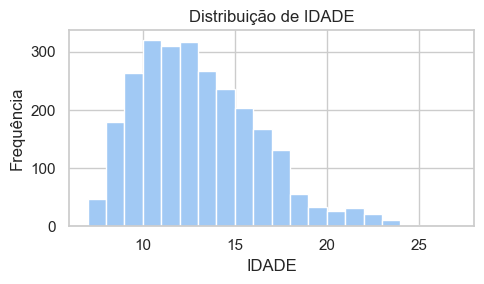

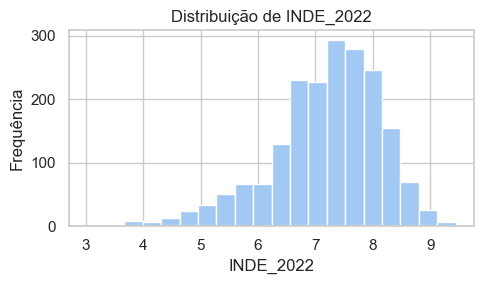

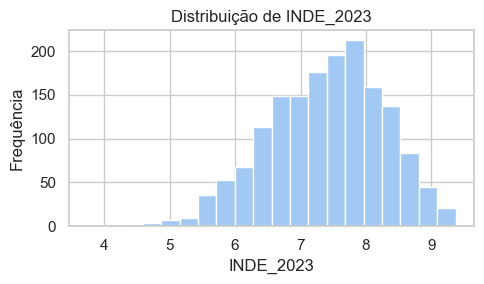

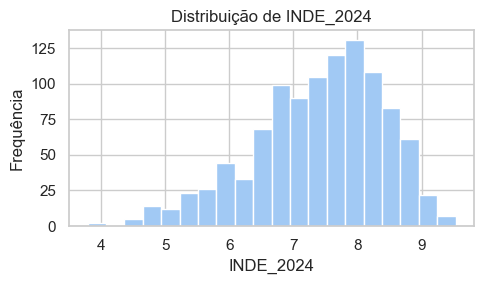

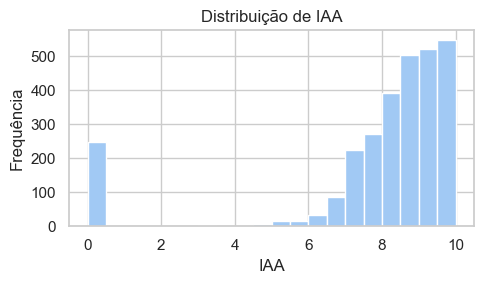

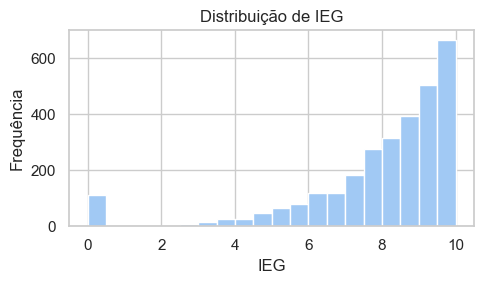

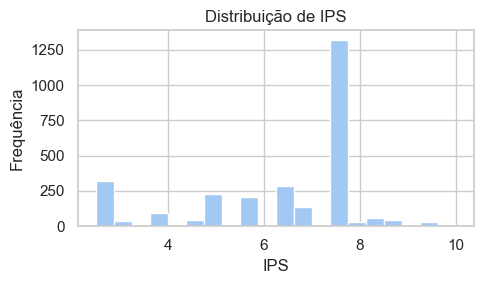

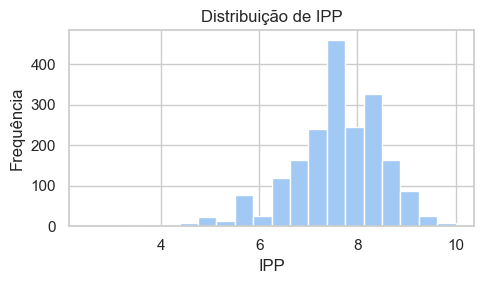

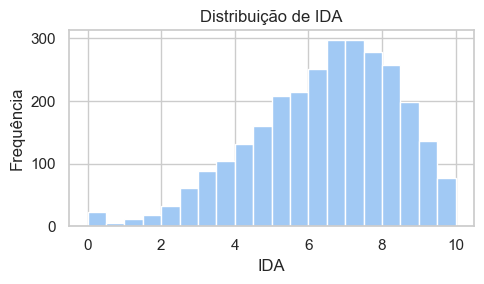

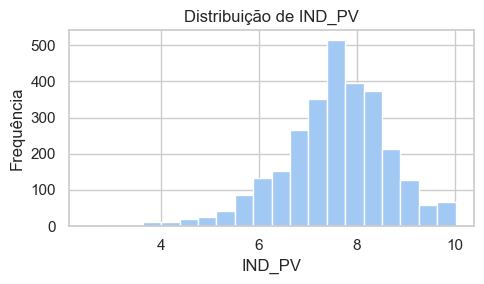

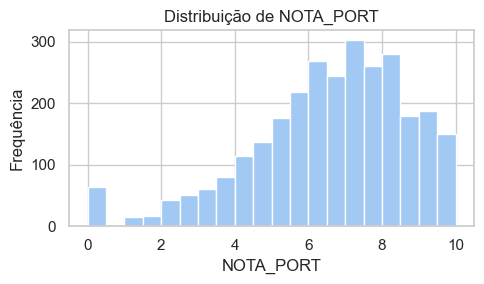

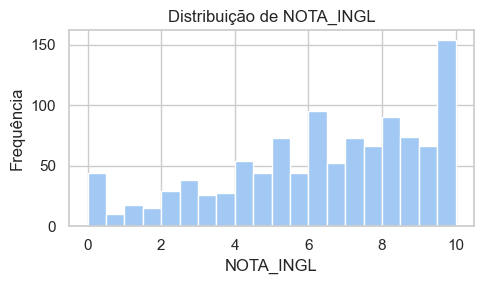

In [16]:
cols_plot = [c for c in ["IDADE", "INDE_2022", "INDE_2023", "INDE_2024",
                         "IAA", "IEG", "IPS", "IPP", "IDA", "IND_PV", "IAN"
                         "NOTA_MATEM", "NOTA_PORT", "NOTA_INGL"] 
             if c in df.columns]

for col in cols_plot:
    serie = pd.to_numeric(df[col], errors="coerce").dropna()
    
    if serie.empty:
        print(f"Pulei {col}: não sobrou dado numérico após conversão.")
        continue
    
    plt.figure(figsize=(5,3))
    plt.hist(serie, bins=20)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

GENERO
Feminino     1169
Masculino    1001
Menina        457
Menino        403
Name: count, dtype: int64

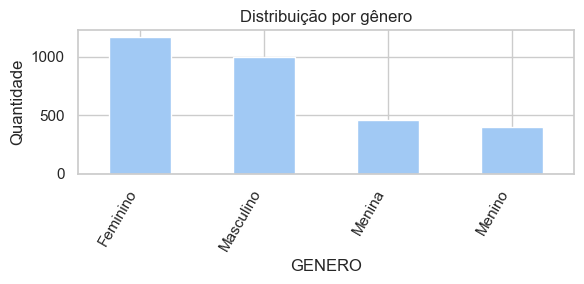

INSTITUICAO_ENSINO
Pública                                      1722
Escola Pública                                752
Privada - Programa de Apadrinhamento          194
Rede Decisão                                  106
Privada                                       104
Privada *Parcerias com Bolsa 100%             101
Privada - Pagamento por *Empresa Parceira      17
Concluiu o 3º EM                               14
Bolsista Universitário *Formado (a)            13
Escola JP II                                    2
Privada - Programa de apadrinhamento            2
Nenhuma das opções acima                        2
NaN                                             1
Name: count, dtype: int64

C:\Users\Joyce\AppData\Local\Temp\ipykernel_7448\973288655.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


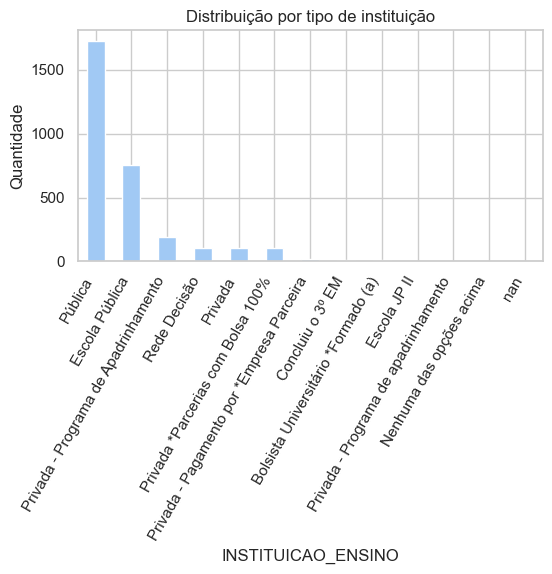

ANO_INGRESSO
2022    881
2021    620
2023    617
2024    349
2019    237
2018    113
2020     88
2017     72
2016     53
Name: count, dtype: int64

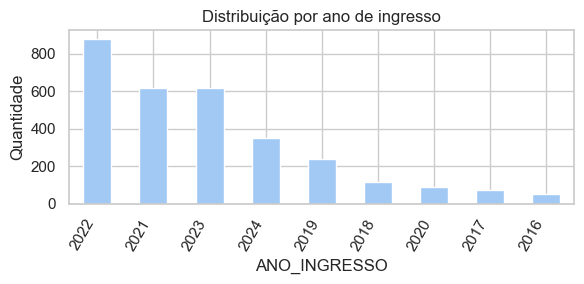

In [17]:
def bar_count(series, titulo, top=15):
    vc = series.value_counts(dropna=False).head(top)
    display(vc)
    
    ax = vc.plot(kind="bar", figsize=(6,3))
    ax.set_title(titulo)
    ax.set_ylabel("Quantidade")
    ax.set_xlabel(series.name)
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

if "GENERO" in df.columns:
    bar_count(df["GENERO"], "Distribuição por gênero")

if "INSTITUICAO_ENSINO" in df.columns:
    bar_count(df["INSTITUICAO_ENSINO"], "Distribuição por tipo de instituição")

if "ANO_INGRESSO" in df.columns:
    bar_count(df["ANO_INGRESSO"], "Distribuição por ano de ingresso")

🔹 2. Análise do target

POSSUI_DEFASAGEM
1    0.556766
0    0.443234
Name: proporcao, dtype: float64

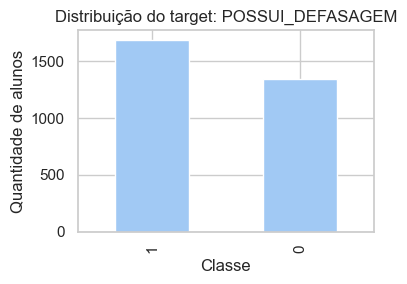

In [18]:
target_col = "POSSUI_DEFASAGEM"

dist = df[target_col].value_counts(normalize=True).rename("proporcao")
display(dist)

plt.figure(figsize=(4,3))
df[target_col].value_counts().plot(kind="bar")
plt.title(f"Distribuição do target: {target_col}")
plt.xlabel("Classe")
plt.ylabel("Quantidade de alunos")
plt.tight_layout()
plt.show()

ANO
2022    0.698837
2023    0.544379
2024    0.461938
Name: taxa_defasagem, dtype: float64

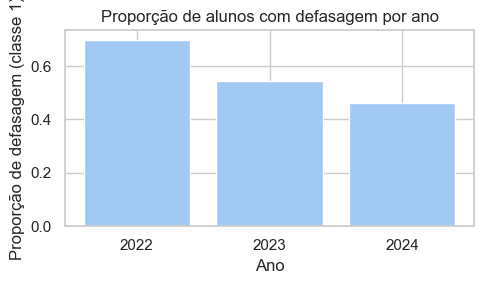

In [19]:
if "ANO" in df.columns:
    taxa_por_ano = df.groupby("ANO")[target_col].mean().rename("taxa_defasagem")
    display(taxa_por_ano)

    plt.figure(figsize=(5,3))
    plt.bar(taxa_por_ano.index.astype(str), taxa_por_ano.values)
    plt.title("Proporção de alunos com defasagem por ano")
    plt.xlabel("Ano")
    plt.ylabel("Proporção de defasagem (classe 1)")
    plt.tight_layout()
    plt.show()

In [20]:
if "INSTITUICAO_ENSINO" in df.columns:
    taxa_por_escola = pd.crosstab(df["INSTITUICAO_ENSINO"], df[target_col],
                                  normalize="index")
    display(taxa_por_escola.sort_values(by=1, ascending=False).head(15))

POSSUI_DEFASAGEM,0,1
INSTITUICAO_ENSINO,,
Escola JP II,0.000000,1.000000
Nenhuma das opções acima,0.000000,1.000000
Privada - Programa de apadrinhamento,0.000000,1.000000
Escola Pública,0.263298,0.736702
Concluiu o 3º EM,0.285714,0.714286
Pública,0.418118,0.581882
Rede Decisão,0.575472,0.424528
Privada,0.740385,0.259615
Privada - Programa de Apadrinhamento,0.783505,0.216495


POSSUI_DEFASAGEM,0,1
FAIXA_IDADE,,
≤10,0.415536,0.584464
11–12,0.414013,0.585987
13–14,0.565476,0.434524
15–16,0.295699,0.704301
≥17,0.427419,0.572581


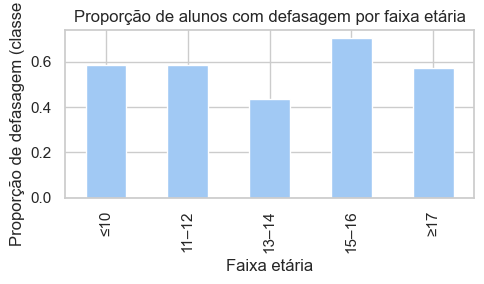

In [21]:
if "IDADE" in df.columns:
    df["IDADE_NUM"] = pd.to_numeric(df["IDADE"], errors="coerce")

    bins = [5, 10, 12, 14, 16, 20]
    labels = ["≤10", "11–12", "13–14", "15–16", "≥17"]
    df["FAIXA_IDADE"] = pd.cut(df["IDADE_NUM"], bins=bins, labels=labels, right=True, include_lowest=True)

    taxa_idade = pd.crosstab(df["FAIXA_IDADE"], df[target_col], normalize="index")
    display(taxa_idade)

    ax = taxa_idade[1].plot(kind="bar", figsize=(5,3))
    ax.set_title("Proporção de alunos com defasagem por faixa etária")
    ax.set_xlabel("Faixa etária")
    ax.set_ylabel("Proporção de defasagem (classe 1)")
    plt.tight_layout()
    plt.show()